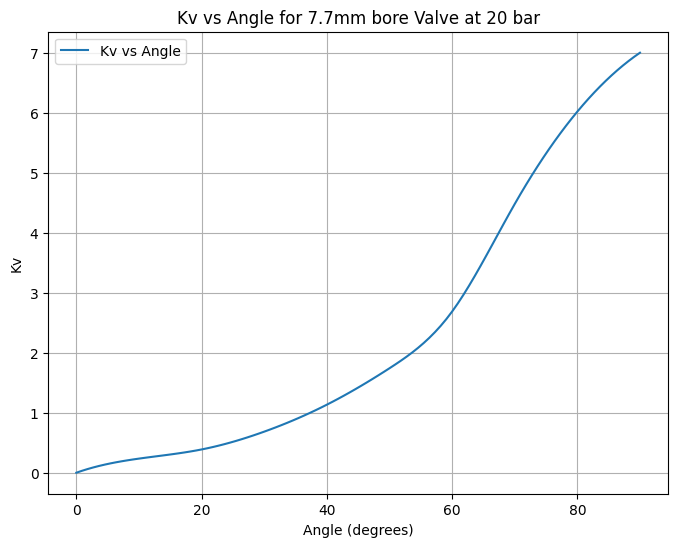

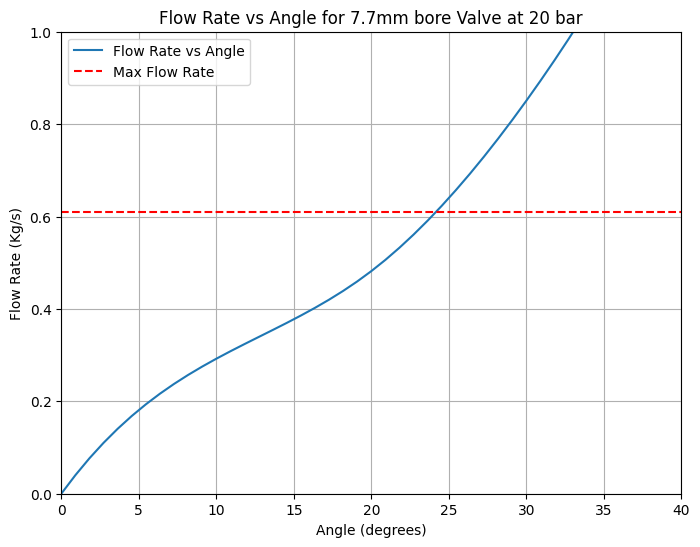

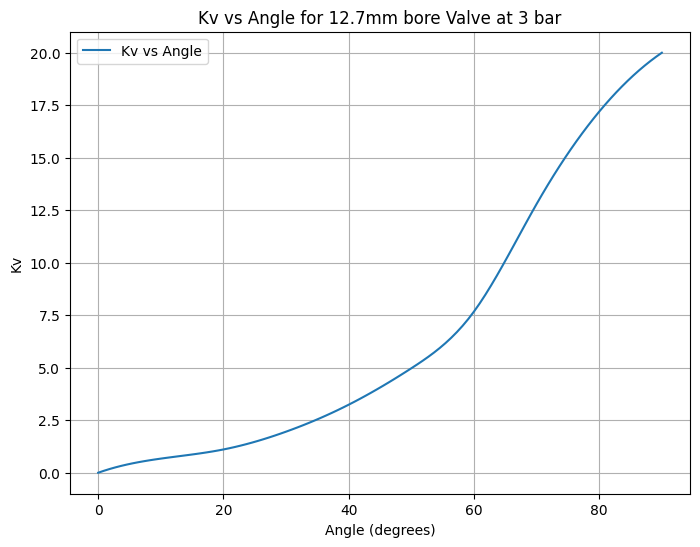

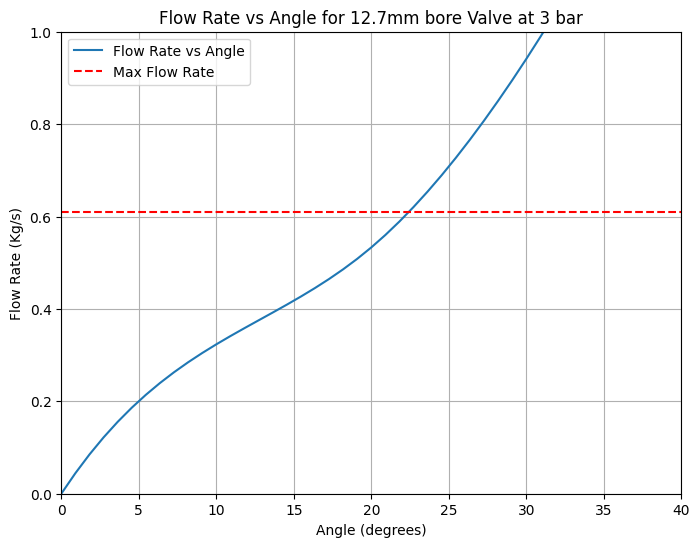

In [94]:
from scipy.interpolate import interp1d
angle = [0.00,10.00,20.00,30.00,40.00,50.00,60.00,70.00,80.00,90.00]
ratio = [0.0000,0.0336,0.0554,0.0978,0.1620,0.2487,0.3837,0.6398,0.8598,1.0000]

diameter = [12.7,19.05,25.4,38.1,50.8,63.5,76.2,101.6,152.4,203.2,254  ,304.8,355.6,406.4]
kv =       [26  ,50   ,94  ,260 ,480 ,750 ,1300,2300 ,5400 ,10000,16000,24000,31400,43000]

# Create interpolation functions
angle_to_ratio = interp1d(angle, ratio, kind='cubic', fill_value="extrapolate")
diameter_to_kv = interp1d(diameter, kv, kind='cubic', fill_value="extrapolate")

import matplotlib.pyplot as plt
import numpy as np

# # Plotting the interpolation functions
# fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# ax[0].plot(angle, ratio, 'o', label='Data Points')
# angle_range = np.linspace(min(angle), max(angle), 100)
# ratio_range = angle_to_ratio(angle_range)
# ax[0].plot(angle_range, ratio_range, label='Cubic Interpolation')
# ax[0].set_title('Angle to Ratio')
# ax[0].set_xlabel('Angle (degrees)')
# ax[0].set_ylabel('Ratio')
# ax[0].legend()
# ax[1].plot(diameter, kv, 'o', label='Data Points')
# diameter_range = np.linspace(min(diameter), max(diameter), 100)
# kv_range = diameter_to_kv(diameter_range)
# ax[1].plot(diameter_range, kv_range, label='Cubic Interpolation')
# ax[1].set_title('Diameter to Kv')
# ax[1].set_xlabel('Diameter (mm)')
# ax[1].set_ylabel('Kv')
# ax[1].legend()
# plt.tight_layout()
# plt.show()

# kv_1_4 = diameter_to_kv(25.4/4)

# diameter_range = np.linspace(0, 50, 100)
# kv_range = diameter_to_kv(diameter_range)
# plt.figure(figsize=(8, 6))
# plt.plot(diameter_range, kv_range, label='Kv vs Diameter')
# # Plot original data points for reference
# plt.plot(diameter, kv, 'o', label='Data Points')
# plt.title('Kv vs Diameter for 7mm to 20mm')
# plt.xlabel('Diameter (mm)')
# plt.ylabel('Kv')
# plt.legend()
# plt.grid()
# plt.xlim(0, 50)
# plt.ylim(0, 100)
# # Highlight the 1/4" diameter point
# plt.plot(25.4/4, kv_1_4, 'ro', label='Kv at 1/4"')
# plt.show()

# Hard code 7.7mm hole kv
kv_1_4 = 7
head = 20 # bar

# find kv vs angle
angle_range = np.linspace(0, 90, 100)
ratio_range = angle_to_ratio(angle_range)
kv_range = kv_1_4 * ratio_range
plt.figure(figsize=(8, 6))
plt.plot(angle_range, kv_range, label='Kv vs Angle')
plt.title('Kv vs Angle for 7.7mm bore Valve at 20 bar')
plt.xlabel('Angle (degrees)')
plt.ylabel('Kv')
plt.legend()
plt.grid()
plt.show()

# find flow rate vs angle
angle_range = np.linspace(0, 90, 100)
ratio_range = angle_to_ratio(angle_range)
flow_rate_range = kv_1_4 * ratio_range * np.sqrt(head) * 1/3600 * 1000 # Kg/s

throat_diameter = 0.003
tip_velocity = 61.28

A_throat = throat_diameter * throat_diameter * np.pi / 4
Qmax = A_throat * 1.41 * tip_velocity
mdotmax = Qmax * 1000

# Plot flow rate vs angle
plt.figure(figsize=(8, 6))
plt.plot(angle_range, flow_rate_range, label='Flow Rate vs Angle')

flow_rate_range_2 = flow_rate_range.copy()

plt.title('Flow Rate vs Angle for 7.7mm bore Valve at 20 bar')
plt.xlabel('Angle (degrees)')
plt.ylabel('Flow Rate (Kg/s)')
# draw max flow rate line
plt.axhline(mdotmax, color='r', linestyle='--', label='Max Flow Rate')
plt.legend()
plt.xlim(0,40)
plt.ylim(0, 1)
plt.grid()
plt.show()

# Hard code 12.7mm hole kv
kv_1_4 = 20
head = 3 # bar

# find kv vs angle
angle_range = np.linspace(0, 90, 100)
ratio_range = angle_to_ratio(angle_range)
kv_range = kv_1_4 * ratio_range
plt.figure(figsize=(8, 6))
plt.plot(angle_range, kv_range, label='Kv vs Angle')
plt.title('Kv vs Angle for 12.7mm bore Valve at 3 bar')
plt.xlabel('Angle (degrees)')
plt.ylabel('Kv')
plt.legend()
plt.grid()
plt.show()

# find flow rate vs angle
angle_range = np.linspace(0, 90, 100)
ratio_range = angle_to_ratio(angle_range)
flow_rate_range = kv_1_4 * ratio_range * np.sqrt(head) * 1/3600 * 1000 # Kg/s

A_throat = 0.003 * 0.003 * np.pi / 4
Qmax = A_throat * 1.41 * 61.28 
mdotmax = Qmax * 1000

# Plot flow rate vs angle
plt.figure(figsize=(8, 6))
plt.plot(angle_range, flow_rate_range, label='Flow Rate vs Angle')

flow_rate_range_1 = flow_rate_range.copy()

plt.title('Flow Rate vs Angle for 12.7mm bore Valve at 3 bar')
plt.xlabel('Angle (degrees)')
plt.ylabel('Flow Rate (Kg/s)')
# draw max flow rate line
plt.axhline(mdotmax, color='r', linestyle='--', label='Max Flow Rate')
plt.legend()
plt.xlim(0,40)
plt.ylim(0, 1)
plt.grid()
plt.show()


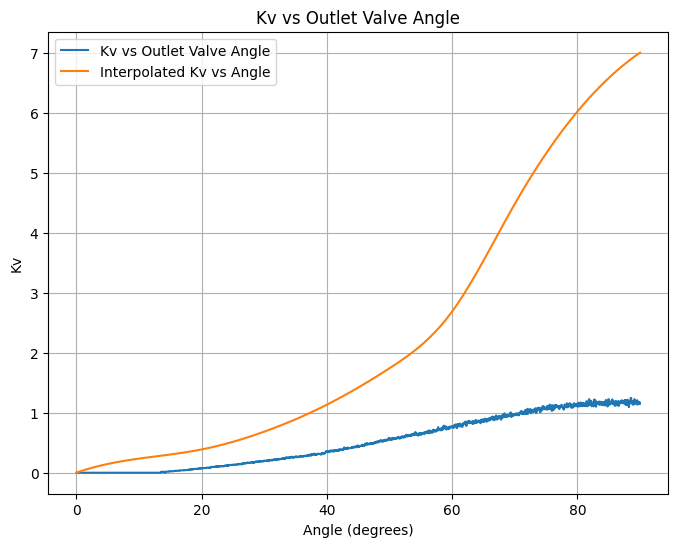

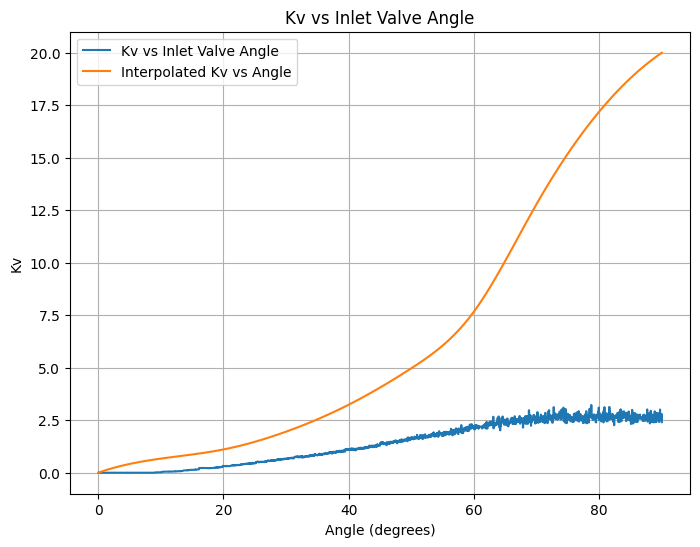

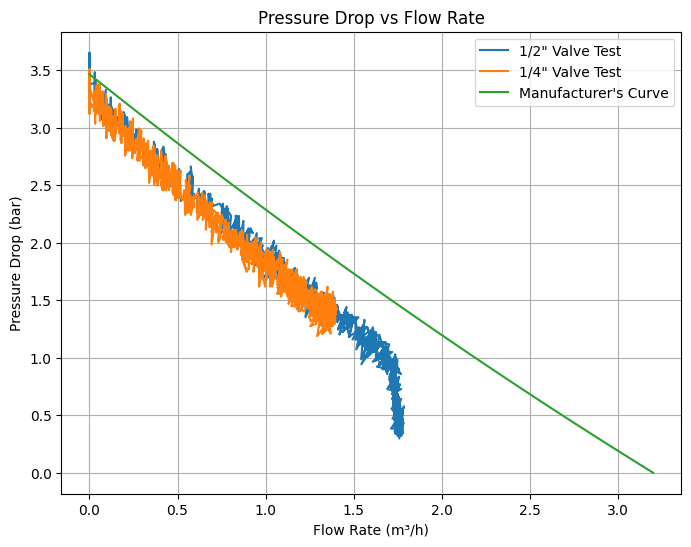

In [ ]:
import h5py
import numpy as np
# 1/4" Valve test

f = h5py.File("D:\\Projects\\propbackend_logs\\2026-04-24\\hotfirelog\\test_20260424_175759_HotfireLog.h5", 'r')
# print(f["channels"].keys())

pt_in = f["channels"]["adc_pt_in_mv"]["data"][:]
pt_out = f["channels"]["adc_pt_out_mv"]["data"][:]
fm = f["channels"]["fms_fm0_flowrate"]["data"][:]
outlet_valve_angle = f["channels"]["servos_pumpoutlet_angle"]["data"][:]
time = f["channels"]["adc_pt_in_mv"]["time"][:]

# Find data where time is betwewen 0 and 180 seconds
mask = (time >= 0) & (time <= 180)
time = time[mask]
pt_in = pt_in[mask]
pt_out = pt_out[mask]
fm = fm[mask]
outlet_valve_angle = 90 - outlet_valve_angle[mask] / 2

kv = fm / 1000 * 3600 / np.sqrt(pt_in - pt_out)

# Compare with previous interpolation
kv_1_4 = 7
# find kv vs angle
angle_range = np.linspace(0, 90, 100)
ratio_range = angle_to_ratio(angle_range)
kv_range = kv_1_4 * ratio_range

plt.figure(figsize=(8, 6))
plt.plot(outlet_valve_angle, kv, label='Kv vs Outlet Valve Angle')
plt.plot(angle_range, kv_range, label='Interpolated Kv vs Angle')
plt.title('Kv vs Outlet Valve Angle')
plt.legend()
plt.xlabel('Angle (degrees)')
plt.ylabel('Kv')
plt.grid()
plt.show()

dp_test2 = pt_in - pt_out
q_test2 = fm / 1000 * 3600
# 1/2" Valve test

f = h5py.File("D:\\Projects\\propbackend_logs\\2026-04-24\\hotfirelog\\test_20260424_171514_HotfireLog.h5", 'r')

pt_in = f["channels"]["adc_pt_in_mv"]["data"][:]
pt_out = f["channels"]["adc_pt_out_mv"]["data"][:]
fm = f["channels"]["fms_fm0_flowrate"]["data"][:]
inlet_valve_angle = f["channels"]["servos_pumpinlet_angle"]["data"][:]
time = f["channels"]["adc_pt_in_mv"]["time"][:]

# Find data where time is betwewen 0 and 180 seconds
mask = (time >= 0) & (time <= 180)
time = time[mask]
pt_in = pt_in[mask]
pt_out = pt_out[mask]
fm = fm[mask]
inlet_valve_angle = 90 - inlet_valve_angle[mask] / 2

kv = fm / 1000 * 3600 / np.sqrt(pt_in - pt_out)
# Compare with previous interpolation
kv_1_2 = 20
# find kv vs angle
angle_range = np.linspace(0, 90, 100)
ratio_range = angle_to_ratio(angle_range)
kv_range = kv_1_2 * ratio_range

plt.figure(figsize=(8, 6))
plt.plot(inlet_valve_angle, kv, label='Kv vs Inlet Valve Angle')
plt.plot(angle_range, kv_range, label='Interpolated Kv vs Angle')
plt.title('Kv vs Inlet Valve Angle')
plt.xlabel('Angle (degrees)')
plt.ylabel('Kv')
plt.legend()
plt.grid()
plt.show()

dp_test1 = pt_in - pt_out
q_test1 = fm / 1000 * 3600

def manufacturer_curve(q):
    # https://www.anglianpumping.com/app/uploads/2023/03/hozelock-jet-3000-manual.pdf
    # https://www.desmos.com/calculator/njmgbobulp
    return 0.417 * q*q + -11.96 * q + 34

plt.figure(figsize=(8, 6))
plt.plot(q_test1, dp_test1, label='1/2" Valve Test')
plt.plot(q_test2, dp_test2, label='1/4" Valve Test')
plt.plot(np.linspace(0, 3.2, 100), manufacturer_curve(np.linspace(0, 3.2, 100))/9.81, label="Manufacturer's Curve")
plt.title('Pressure Drop vs Flow Rate')
plt.xlabel('Flow Rate (m³/h)')
plt.ylabel('Pressure Drop (bar)')
plt.grid()
plt.legend()

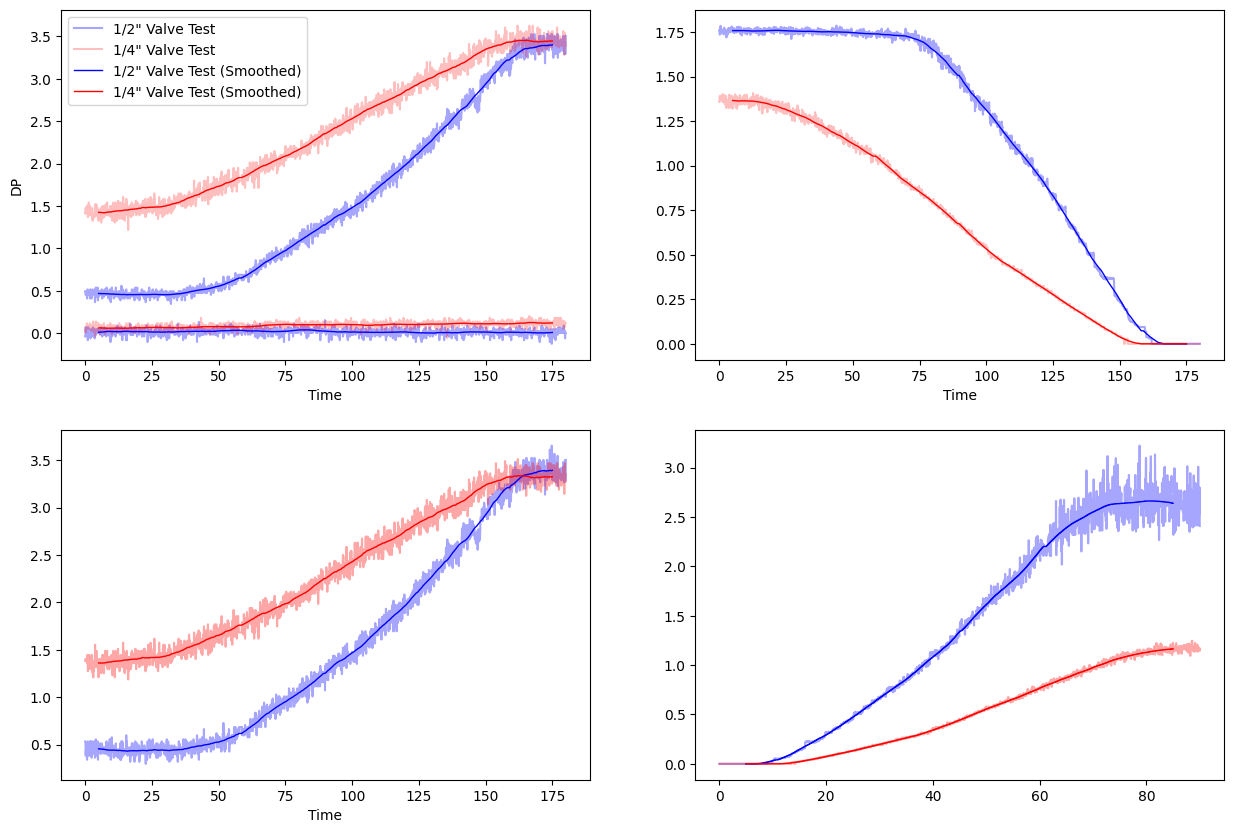

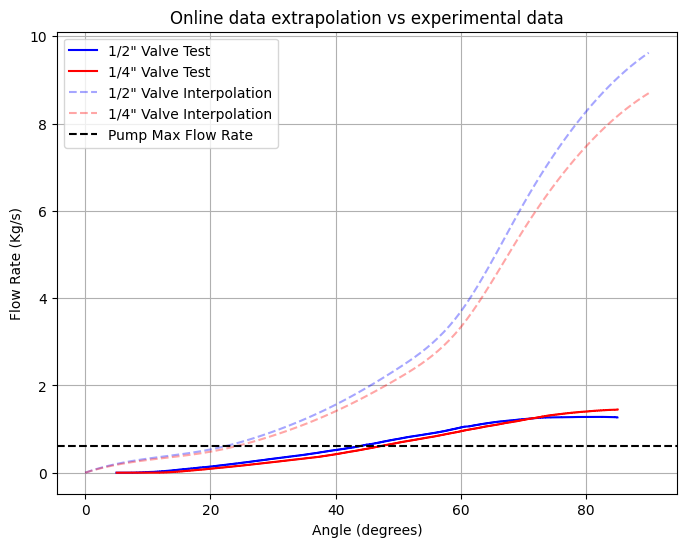

In [99]:
import polars as pl

f_outlet = h5py.File("D:\\Projects\\propbackend_logs\\2026-04-24\\hotfirelog\\test_20260424_175759_HotfireLog.h5", 'r')
f_inlet = h5py.File("D:\\Projects\\propbackend_logs\\2026-04-24\\hotfirelog\\test_20260424_171514_HotfireLog.h5", 'r')

p_in_1 = f_inlet["channels"]["adc_pt_in_mv"]["data"][:]
p_out_1 = f_inlet["channels"]["adc_pt_out_mv"]["data"][:]
q_1 = f_inlet["channels"]["fms_fm0_flowrate"]["data"][:] / 1000 * 3600
p_in_2 = f_outlet["channels"]["adc_pt_in_mv"]["data"][:]
p_out_2 = f_outlet["channels"]["adc_pt_out_mv"]["data"][:]
q_2 = f_outlet["channels"]["fms_fm0_flowrate"]["data"][:] / 1000 * 3600
time = f_inlet["channels"]["adc_pt_in_mv"]["time"][:]
inlet_angle = 90 - f_inlet["channels"]["servos_pumpinlet_angle"]["data"][:] / 2
outlet_angle = 90 - f_outlet["channels"]["servos_pumpoutlet_angle"]["data"][:] / 2

# make a dataframe containing all the data
df = pl.DataFrame({
    "time": time,
    "p_in_1": p_in_1,
    "p_out_1": p_out_1,
    "q_1": q_1,
    "p_in_2": p_in_2,
    "p_out_2": p_out_2,
    "q_2": q_2,
    "inlet_angle": inlet_angle,
    "outlet_angle": outlet_angle
})

# Cut data to 0-180 seconds
df = df.filter((df["time"] >= 0) & (df["time"] <= 180))

fig, ax = plt.subplots(2,2,figsize=(15, 10))
ax[0,0].plot(df["time"], df["p_in_1"], label='1/2" Valve Test', color='blue', alpha=0.35)
ax[0,0].plot(df["time"], df["p_out_1"], label="_", color='blue', alpha=0.35)
ax[0,0].plot(df["time"], df["p_in_2"], label='1/4" Valve Test', color='red', alpha=0.25)
ax[0,0].plot(df["time"], df["p_out_2"], label="_", color='red', alpha=0.25)
ax[0,0].plot(df["time"], df["p_in_1"].rolling_mean(1000, center=True), label='1/2" Valve Test (Smoothed)', color='blue', linewidth=1)
ax[0,0].plot(df["time"], df["p_out_1"].rolling_mean(1000, center=True), label="_", color='blue', linewidth=1)
ax[0,0].plot(df["time"], df["p_in_2"].rolling_mean(1000, center=True), label='1/4" Valve Test (Smoothed)', color='red', linewidth=1)
ax[0,0].plot(df["time"], df["p_out_2"].rolling_mean(1000, center=True), label="_", color='red', linewidth=1)
ax[0,0].set_xlabel('Time')
ax[0,0].set_ylabel('DP')
ax[0,0].legend()
ax[0,1].plot(df["time"], df["q_1"], label='1/2" Valve Test', color='blue', alpha=0.35)
ax[0,1].plot(df["time"], df["q_2"], label='1/4" Valve Test', color='red', alpha=0.25)
ax[0,1].plot(df["time"], df["q_1"].rolling_mean(1000, center=True), label='1/2" Valve Test (Smoothed)', color='blue', linewidth=1)
ax[0,1].plot(df["time"], df["q_2"].rolling_mean(1000, center=True), label='1/4" Valve Test (Smoothed)', color='red', linewidth=1)
ax[0,1].set_xlabel('Time')

dp_1 = df["p_in_1"] - df["p_out_1"]
dp_2 = df["p_in_2"] - df["p_out_2"]

ax[1,0].plot(df["time"], dp_1, label='1/2" Valve Test', color='blue', alpha=0.35)
ax[1,0].plot(df["time"], dp_2, label='1/4" Valve Test', color='red', alpha=0.35)
ax[1,0].plot(df["time"], dp_1.rolling_mean(1000, center=True), label='1/2" Valve Test (Smoothed)', color='blue', linewidth=1)
ax[1,0].plot(df["time"], dp_2.rolling_mean(1000, center=True), label='1/4" Valve Test (Smoothed)', color='red', linewidth=1)

q_1 = df["q_1"]
q_2 = df["q_2"]

kv_1 = q_1 / np.sqrt(dp_1)
kv_2 = q_2 / np.sqrt(dp_2)

dp_1 = df["p_in_1"].rolling_mean(1000, center=True) - df["p_out_1"].rolling_mean(1000, center=True)
dp_2 = df["p_in_2"].rolling_mean(1000, center=True) - df["p_out_2"].rolling_mean(1000, center=True)
# ax[1,0].plot(df["time"], dp_1.rolling_mean(1000, center=True), label='1/2" Valve Test (Smoothed x2)', color='black', linewidth=1)
# ax[1,0].plot(df["time"], dp_2.rolling_mean(1000, center=True), label='1/4" Valve Test (Smoothed x2)', color='black', linewidth=1)

ax[1,0].set_xlabel('Time')

ax[1,1].plot(df["inlet_angle"], kv_1, label='1/2" Valve Test', color='blue', alpha=0.35)
ax[1,1].plot(df["outlet_angle"], kv_2, label='1/4" Valve Test', color='red', alpha=0.35)

q_1 = df["q_1"].rolling_mean(1000, center=True)
q_2 = df["q_2"].rolling_mean(1000, center=True)
dp_1 = dp_1.rolling_mean(1000, center=True)
dp_2 = dp_2.rolling_mean(1000, center=True)

kv_1 = q_1 / np.sqrt(dp_1)
kv_2 = q_2 / np.sqrt(dp_2)

ax[1,1].plot(df["inlet_angle"], kv_1, label='1/2" Valve Test (Smoothed)', color='blue', linewidth=1)
ax[1,1].plot(df["outlet_angle"], kv_2, label='1/4" Valve Test (Smoothed)', color='red', linewidth=1)

plt.show()

from scipy.interpolate import interp1d
angle = np.linspace(0, 90, 100)

# Pump max flow rate
throat_diameter = 0.003
tip_velocity = 61.28
A_throat = throat_diameter * throat_diameter * np.pi / 4
Qmax = A_throat * np.sqrt(2) * tip_velocity
mdotmax = Qmax * 1000

fig, ax = plt.subplots(figsize=(8, 6))
flow_rate_range_1_real = kv_1 * np.sqrt(3) * 1/3600 * 1000
flow_rate_range_2_real = kv_2 * np.sqrt(20) * 1/3600 * 1000
ax.plot(df["inlet_angle"], flow_rate_range_1_real, label='1/2" Valve Test', color='blue')
ax.plot(df["outlet_angle"], flow_rate_range_2_real, label='1/4" Valve Test', color='red')
ax.plot(angle_range, flow_rate_range_1, '--', label='1/2" Valve Interpolation', color='blue', alpha=0.35)
ax.plot(angle_range, flow_rate_range_2, '--', label='1/4" Valve Interpolation', color='red', alpha=0.35)
ax.axhline(mdotmax, color='black', linestyle='--', label='Pump Max Flow Rate')
ax.set_xlabel('Angle (degrees)')
ax.set_ylabel('Flow Rate (Kg/s)')
ax.legend()
ax.grid()
ax.set_title('Online data extrapolation vs experimental data')
plt.show()
